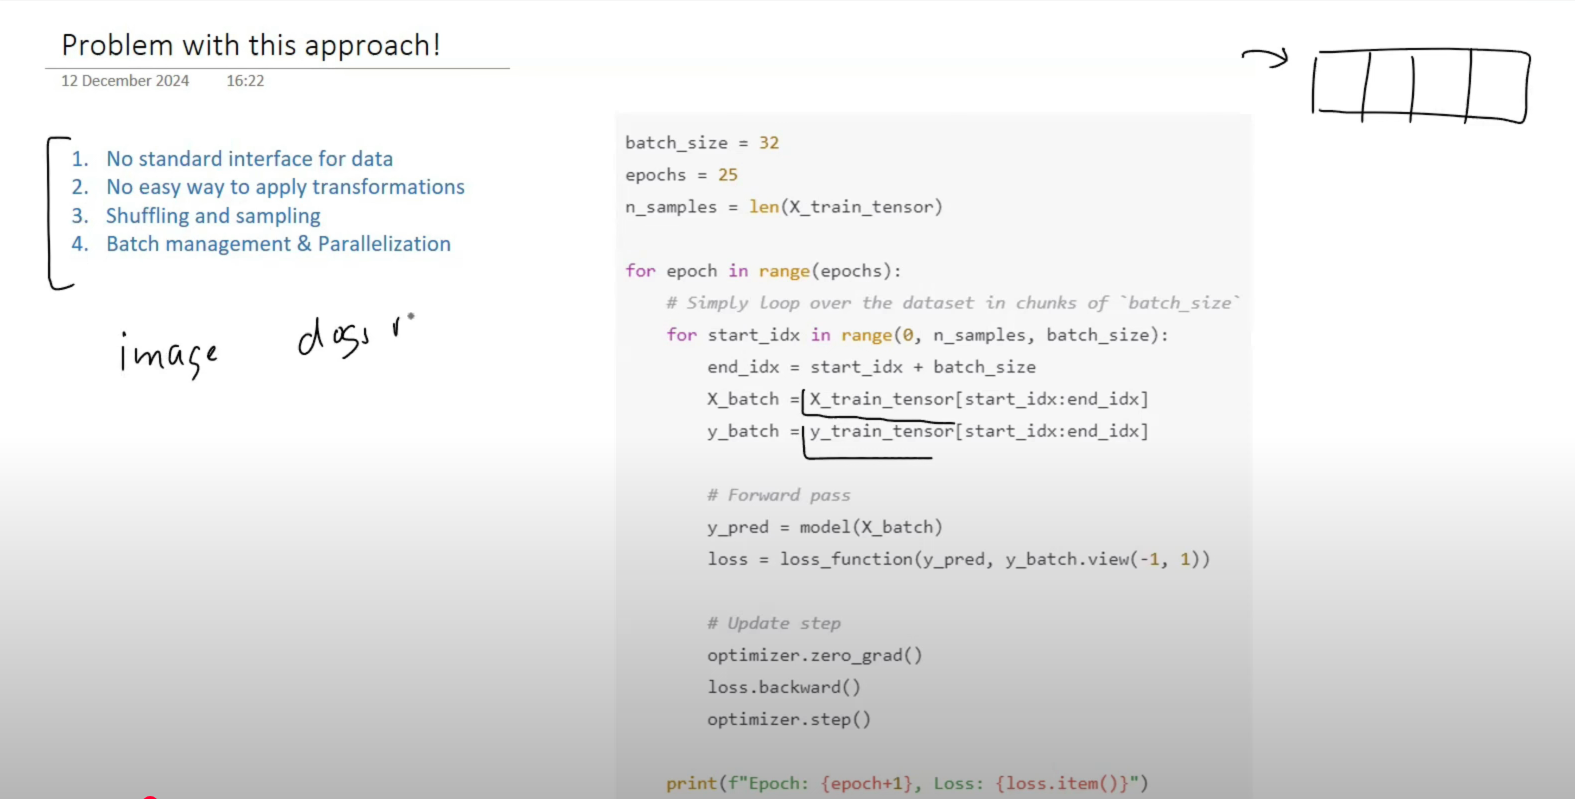

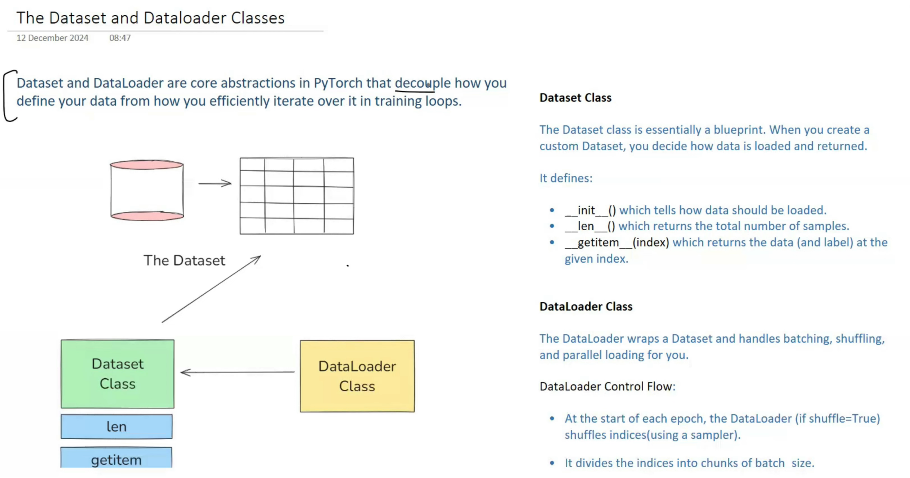

In [ ]:
import torch
from torch.utils.data import Dataset,Dataloader


In [ ]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features = features
    self.labels = labels
  def __len__(self):
    return self.features.shape[0]
  def __getitem__(self,index):
    return self.features[index],self.labels[index]

In [ ]:
dataset = CustomDataset(X,y)

In [ ]:
len(dataset)

In [ ]:
dataset[0]

In [ ]:
dataloader = DataLoader(dataset,batch_size = 4,shuffle= True)

In [ ]:
for batch_features,batch_labels in dataloader:
  print(batch_features)
  print(batch_labels)
  print('*' * 5)

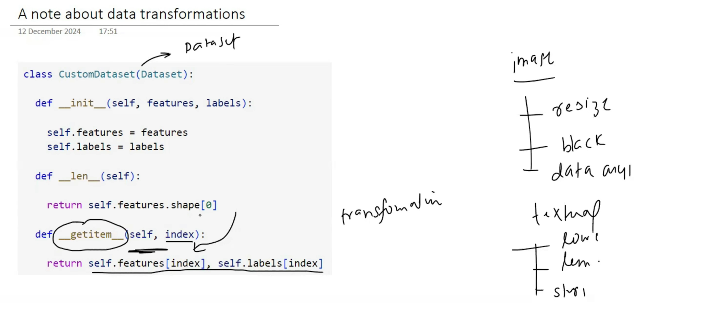

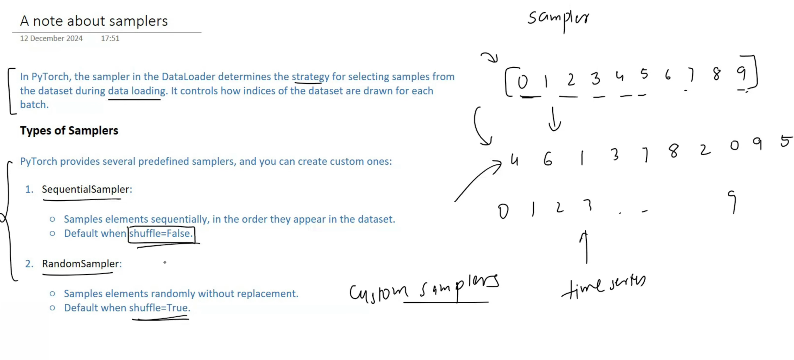

In [ ]:
# Step 1: Import Required Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Step 2: Define a Custom Dataset
class MyDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# Step 3: Define the ANN Model
class SimpleANN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleANN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)  # First layer
        self.fc2 = nn.Linear(hidden_size, output_size)  # Output layer
        self.relu = nn.ReLU()  # Activation function

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Step 4: Initialize the Model, Loss Function, and Optimizer
input_size = 3  # Number of input features
hidden_size = 5  # Number of neurons in the hidden layer
output_size = 2  # Number of output classes

model = SimpleANN(input_size, hidden_size, output_size)
criterion = nn.CrossEntropyLoss()  # Loss function for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Optimizer

# Step 5: Prepare the Data
# Sample data
data = torch.randn(100, input_size)  # 100 samples, 3 features
labels = torch.randint(0, output_size, (100,))  # Random labels for 2 classes

# Create dataset and dataloader
dataset = MyDataset(data, labels)
dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

# Step 6: Train the Model
num_epochs = 20  # Number of training epochs

for epoch in range(num_epochs):
    for batch_data, batch_labels in dataloader:
        # Forward pass
        outputs = model(batch_data)
        loss = criterion(outputs, batch_labels)

        # Backward pass and optimization
        optimizer.zero_grad()  # Clear previous gradients
        loss.backward()  # Compute gradients
        optimizer.step()  # Update weights

    print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')


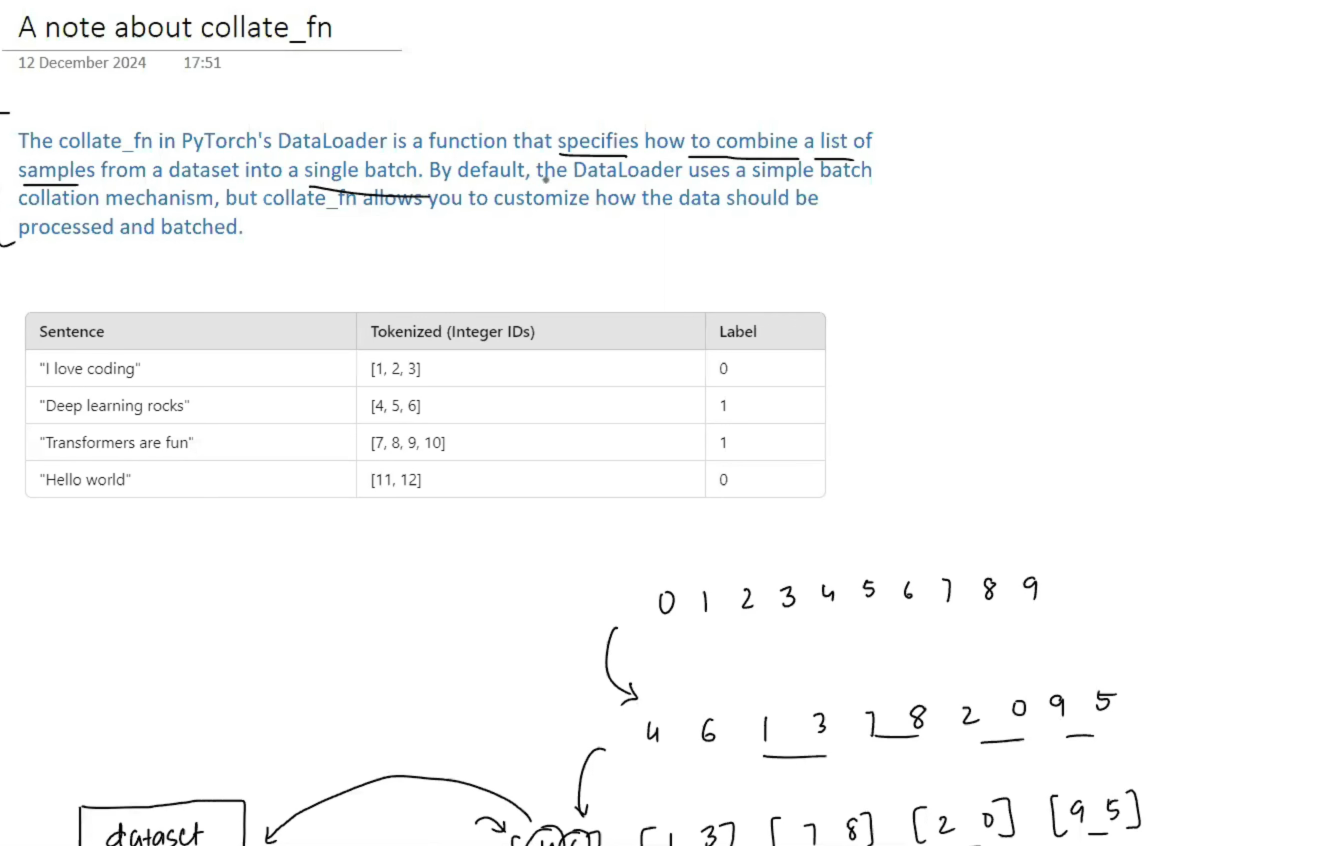

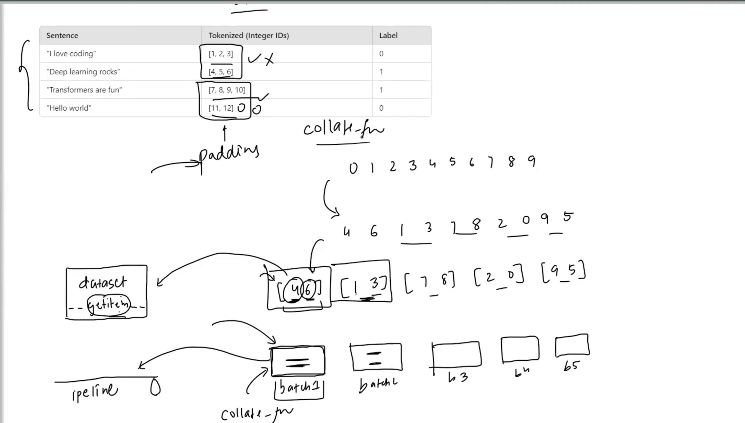

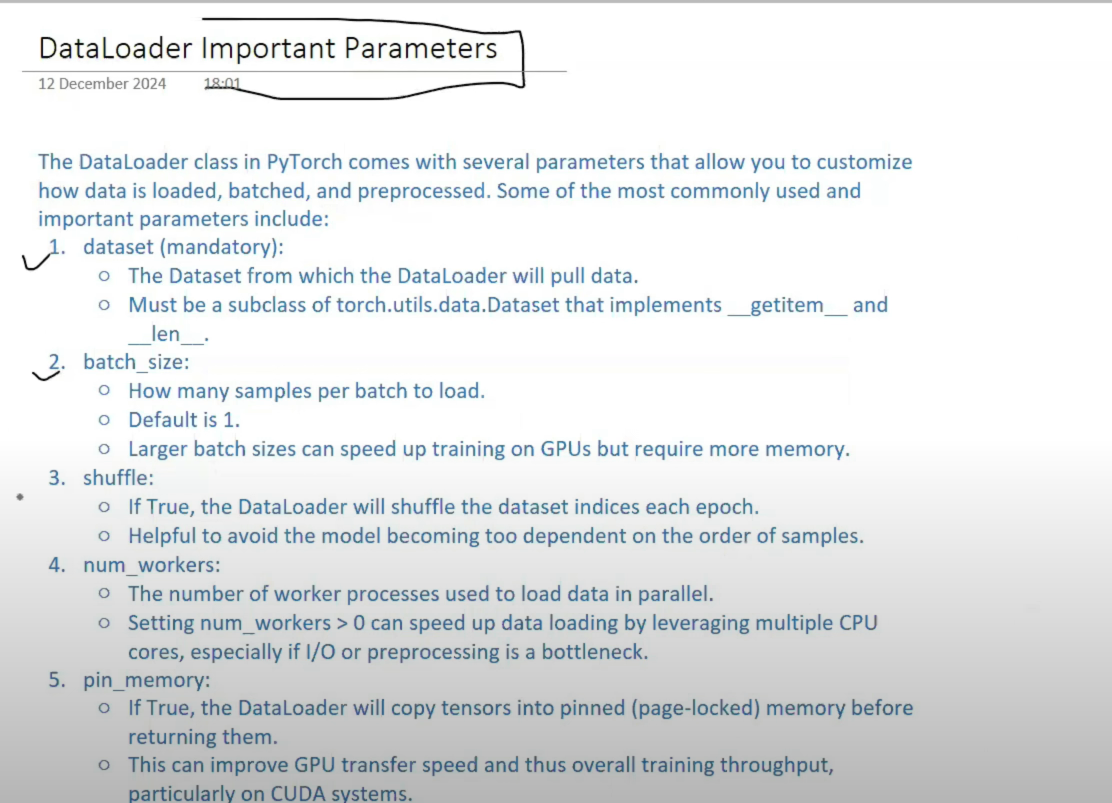

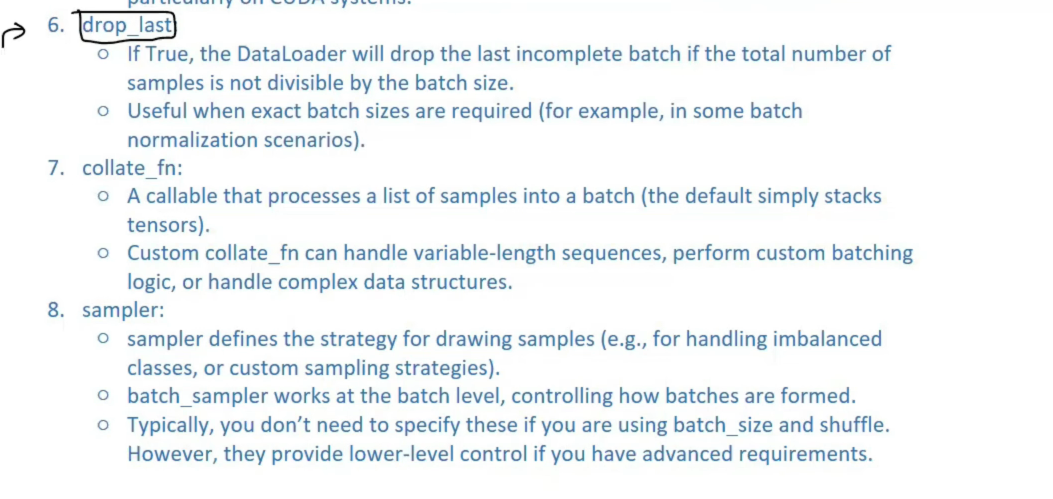